# Energy discrimination: real teams vs. marginal-null teams

**Validation question.** Does the fitted pairwise model assign *lower energy* (higher probability) to **real** teams than to teams built from **marginal usage alone**? If the couplings $J$ carry real structure, an observed team should sit lower on the energy surface than a team assembled by drawing popular Pokémon independently.

Raw energy is $H(s) = -h\cdot s - \tfrac{1}{2}\,s'Js$, so the **Score** $-H(s) = \underbrace{h\cdot s}_{\text{popularity}} + \underbrace{\tfrac{1}{2}s'Js}_{\text{coherence } \Sigma J}$ splits additively into a **popularity term** ($h\cdot s$) and a **coherence term** ($\Sigma J$, the intra-team pairwise sum).

**Why the decomposition matters.** $h$ is fit (by pseudo-likelihood) to reproduce the marginals, and the null teams are drawn *from those same marginals* — so both populations are made of popular Pokémon and will score similarly on the popularity term. Any honest separation must therefore live in the **coherence term**. Reporting full Score alone would partly bake in the answer ("the model was fit to like real teams"); decomposing into $h\cdot s$ vs. $\Sigma J$ isolates the claim we actually care about: *the pairwise couplings encode structure beyond marginals.* This is the [Schneidman et al. 2006](https://doi.org/10.1038/nature04701) pairwise-vs-independent comparison, in VGC form.

**What this is and isn't.** This is a **discrimination** test — can the model's Score separate real teams from a marginal null? It complements the **calibration** test in `validation.ipynb` (held-out completion accuracy); neither subsumes the other. Expect the separation to be *large*, possibly near-trivially so (real teams contain tight archetype cores; the null randomly mixes incompatible ones). A big margin confirms $J$ captures real co-occurrence structure; it does **not** by itself establish calibration.

**No leakage.** The model is fit on the chronological **train** split only (oldest ~90% of teams by tournament date); real teams scored here are the **held-out test** teams from future tournaments; null teams are drawn from **train** marginals. So the separation is not inflated by the model having seen the real teams it scores.

In [ ]:
from __future__ import annotations
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata

from k2dex import tournament_ingest
from k2dex.constants import (
    PHASE2_MIN_TEAM_COUNT, SPECIES_LR_C, SPECIES_ITEM_LR_C,
    TEAM_SIZE, VALIDATION_SEED, VALIDATION_TEAM_FRAC_TEST,
)
from k2dex.models import fit_pl_ising
from k2dex.sampling import team_energy
from k2dex.rendering import intra_team_sum_j

tournaments = tournament_ingest.load_cached_tournaments()
print(f"tournaments:            {len(tournaments)}")
print(f"total team-appearances: {sum(len(t.teams) for t in tournaments)}")

## Train/test split

Chronological 90/10, identical to `validation.ipynb`. Tournaments sorted oldest-first; the oldest ~90% of teams (by tournament boundary) form the train set. The model is fit on train; the **real** population scored below is the held-out test set from future tournaments.

In [2]:
from k2dex.constants import VALIDATION_TEAM_FRAC_TEST, VALIDATION_SEED

train_tournaments, test_tournaments = tournament_ingest.chronological_split(
    tournaments, train_frac=1.0 - VALIDATION_TEAM_FRAC_TEST,
)

train_teams_full = tournament_ingest.all_teams(train_tournaments)
test_teams_full = tournament_ingest.all_teams(test_tournaments)
train_teams = tournament_ingest.species_only_teams(train_teams_full)

n_total = len(train_teams_full) + len(test_teams_full)
print(
    f"chronological split (test_frac={VALIDATION_TEAM_FRAC_TEST:.0%})\n"
    f"train: {len(train_teams_full):>6} teams ({len(train_teams_full)/n_total:.1%})  "
    f"{train_tournaments[0].meta.date} -> {train_tournaments[-1].meta.date}\n"
    f"test:  {len(test_teams_full):>6} teams ({len(test_teams_full)/n_total:.1%})  "
    f"{test_tournaments[0].meta.date} -> {test_tournaments[-1].meta.date}"
)

chronological split (test_frac=10%)
train:  13256 teams (91.4%)  2026-04-09T16:00:00.000Z -> 2026-05-09T15:00:00.000Z
test:    1250 teams (8.6%)  2026-05-10T00:00:00.000Z -> 2026-05-25T01:00:00.000Z


## Phase 2 fit (species vocab)

Species vocab, marginal $m$, and the PL fit $(J, h)$ are all built from **train** teams only (cutoff `PHASE2_MIN_TEAM_COUNT`). Train-only vocab keeps model and features consistent — a test team with a member unseen in train is filtered out below rather than leaking into the fit.

In [3]:
def teams_to_matrix(teams, name_to_idx, V):
    X = np.zeros((len(teams), V), dtype=np.int8)
    for ti, team in enumerate(teams):
        for name in team:
            j = name_to_idx.get(name)
            if j is not None:
                X[ti, j] = 1
    return X

species_counts = Counter(name for team in train_teams for name in team)
vocab = sorted(name for name, c in species_counts.items() if c >= PHASE2_MIN_TEAM_COUNT)
name_to_idx = {name: i for i, name in enumerate(vocab)}
V = len(vocab)

X_train = teams_to_matrix(train_teams, name_to_idx, V)
m_train = X_train.mean(axis=0)
J, h = fit_pl_ising(X_train.astype(np.int32), C=SPECIES_LR_C)

print(f"species vocab size: {V}")
print(f"m_train range:      [{m_train.min():.4f}, {m_train.max():.4f}]")
print(f"J off-diag range:   [{J[np.triu_indices(V, 1)].min():+.3f}, {J[np.triu_indices(V, 1)].max():+.3f}]")

species vocab size: 186
m_train range:      [0.0004, 0.4972]
J off-diag range:   [-3.482, +3.003]


## Phase 3 fit ((species, item) pair vocab)

Pair vocab from the **train** pairs; same PL machinery on the wider feature matrix. `pair_species_of` / `pair_item_of` drive the null sampler's no-duplicate-species / no-duplicate-item constraints below.

In [4]:
pair_counts = Counter(pair for team in train_teams_full for pair in team)
pair_vocab = sorted(
    (p for p, c in pair_counts.items() if c >= PHASE2_MIN_TEAM_COUNT),
    key=lambda p: (p[0], p[1] or ""),
)
pair_to_idx = {p: i for i, p in enumerate(pair_vocab)}
V_pair = len(pair_vocab)
pair_species_of = [s for s, _ in pair_vocab]
pair_item_of = [it for _, it in pair_vocab]

X_train_pair = np.zeros((len(train_teams_full), V_pair), dtype=np.int8)
for ti, team in enumerate(train_teams_full):
    for pair in team:
        j = pair_to_idx.get(pair)
        if j is not None:
            X_train_pair[ti, j] = 1
m_train_pair = X_train_pair.mean(axis=0)
J_pair, h_pair = fit_pl_ising(X_train_pair.astype(np.int32), C=SPECIES_ITEM_LR_C)

print(f"pair vocab size:  {V_pair}")
print(f"J off-diag range: [{J_pair[np.triu_indices(V_pair, 1)].min():+.3f}, {J_pair[np.triu_indices(V_pair, 1)].max():+.3f}]")

pair vocab size:  658
J off-diag range: [-6.812, +3.889]


## The marginal null

A null team is **6 distinct features drawn without replacement, weighted by marginal usage $m$**, respecting the same uniqueness constraints the real model enforces: distinct species (Phase 2 & 3) and distinct items (Phase 3). Concretely, draw a feature $\propto m$ from the still-valid pool, remove it plus anything sharing its species or item, renormalize, repeat until the team is full. This is the **independent / factorized model conditioned on team validity** — the exact "built from marginals alone" baseline the validation question asks for.

In [5]:
def sample_marginal_null(m, n_teams, team_size, *, species_of=None, item_of=None, seed=0):
    '''Draw n_teams boolean team vectors: team_size distinct features sampled
    without replacement weighted by m, respecting species/item uniqueness.'''
    rng = np.random.default_rng(seed)
    V = len(m)
    p0 = m / m.sum()

    sp_code = None
    if species_of is not None:
        sp_ids = {s: i for i, s in enumerate(sorted(set(species_of)))}
        sp_code = np.array([sp_ids[s] for s in species_of])
    it_code = None
    if item_of is not None:
        it_ids = {it: i for i, it in enumerate(sorted({x for x in item_of if x is not None}))}
        it_code = np.array([it_ids.get(it, -1) for it in item_of])

    teams = np.zeros((n_teams, V), dtype=bool)
    for t in range(n_teams):
        valid = np.ones(V, dtype=bool)
        picks: list[int] = []
        while len(picks) < team_size:
            w = p0 * valid
            tot = w.sum()
            if tot <= 0:  # over-constrained pool; restart this team
                valid = np.ones(V, dtype=bool)
                picks = []
                continue
            idx = int(rng.choice(V, p=w / tot))
            picks.append(idx)
            valid[idx] = False
            if sp_code is not None:
                valid[sp_code == sp_code[idx]] = False
            if it_code is not None and it_code[idx] >= 0:
                valid[it_code == it_code[idx]] = False
        teams[t, picks] = True
    return teams

## Real teams + matched nulls

Filter test teams to those fully in-vocab (all 6 members representable), then draw an equal number of marginal-null teams. Phase 2 needs only distinct species; Phase 3 enforces distinct species **and** distinct items, matching the real sampler's uniqueness rules.

In [6]:
# Phase 2 real teams (species granularity)
test_teams_species = tournament_ingest.species_only_teams(test_teams_full)
real_sp = []
for team in test_teams_species:
    if len(team) == TEAM_SIZE and all(s in name_to_idx for s in team):
        v = np.zeros(V, dtype=bool)
        for s in team:
            v[name_to_idx[s]] = True
        real_sp.append(v)
real_sp = np.array(real_sp)

# Phase 3 real teams (pair granularity)
real_pair = []
for team in test_teams_full:
    if len(team) == TEAM_SIZE and all(p in pair_to_idx for p in team):
        v = np.zeros(V_pair, dtype=bool)
        for p in team:
            v[pair_to_idx[p]] = True
        real_pair.append(v)
real_pair = np.array(real_pair)

null_sp = sample_marginal_null(m_train, len(real_sp), TEAM_SIZE, seed=VALIDATION_SEED)
null_pair = sample_marginal_null(
    m_train_pair, len(real_pair), TEAM_SIZE,
    species_of=pair_species_of, item_of=pair_item_of, seed=VALIDATION_SEED,
)

print(f"Phase 2: {len(real_sp)} real / {len(null_sp)} null   (in-vocab of {len(test_teams_species)} test teams)")
print(f"Phase 3: {len(real_pair)} real / {len(null_pair)} null   (in-vocab of {len(test_teams_full)} test teams)")

Phase 2: 1249 real / 1249 null   (in-vocab of 1250 test teams)
Phase 3: 1128 real / 1128 null   (in-vocab of 1250 test teams)


## Score decomposition

For each team, Score $= -H = h\cdot s + \Sigma J$ splits into the **popularity** term $h\cdot s$ and the **coherence** term $\Sigma J = \tfrac{1}{2}s'Js$ (`rendering.intra_team_sum_j`). The full Score equals `-team_energy(...)`; we verify the additive split holds to floating point on the real Phase 2 set.

In [7]:
def score_components(teams_bool, J, h):
    s = teams_bool.astype(np.float64)
    pop = s @ h                              # h . s
    coh = 0.5 * np.sum(s * (s @ J), axis=1)  # 0.5 s'Js  == intra_team_sum_j
    return pop + coh, pop, coh               # Score (= -H), popularity, coherence

real_sp_score, real_sp_pop, real_sp_coh = score_components(real_sp, J, h)
null_sp_score, null_sp_pop, null_sp_coh = score_components(null_sp, J, h)
real_pr_score, real_pr_pop, real_pr_coh = score_components(real_pair, J_pair, h_pair)
null_pr_score, null_pr_pop, null_pr_coh = score_components(null_pair, J_pair, h_pair)

# Cross-check against the library energy + coherence helpers on one team.
i = 0
assert np.isclose(real_sp_score[i], -team_energy(real_sp[i], J, h))
assert np.isclose(real_sp_coh[i], intra_team_sum_j(real_sp[i], J))
print("decomposition matches team_energy / intra_team_sum_j  ✓")
print(f"Phase 2  Score  median  real {np.median(real_sp_score):+.3f}   null {np.median(null_sp_score):+.3f}")
print(f"Phase 3  Score  median  real {np.median(real_pr_score):+.3f}   null {np.median(null_pr_score):+.3f}")

decomposition matches team_energy / intra_team_sum_j  ✓
Phase 2  Score  median  real +6.102   null +0.409
Phase 3  Score  median  real -4.361   null -13.322


## Score distributions

Two rows (Phase 2, Phase 3) × three columns (full Score, popularity $h\cdot s$, coherence $\Sigma J$). The story to look for: real and null **overlap on popularity** but **separate on coherence** — and the full-Score separation is driven by that coherence gap.

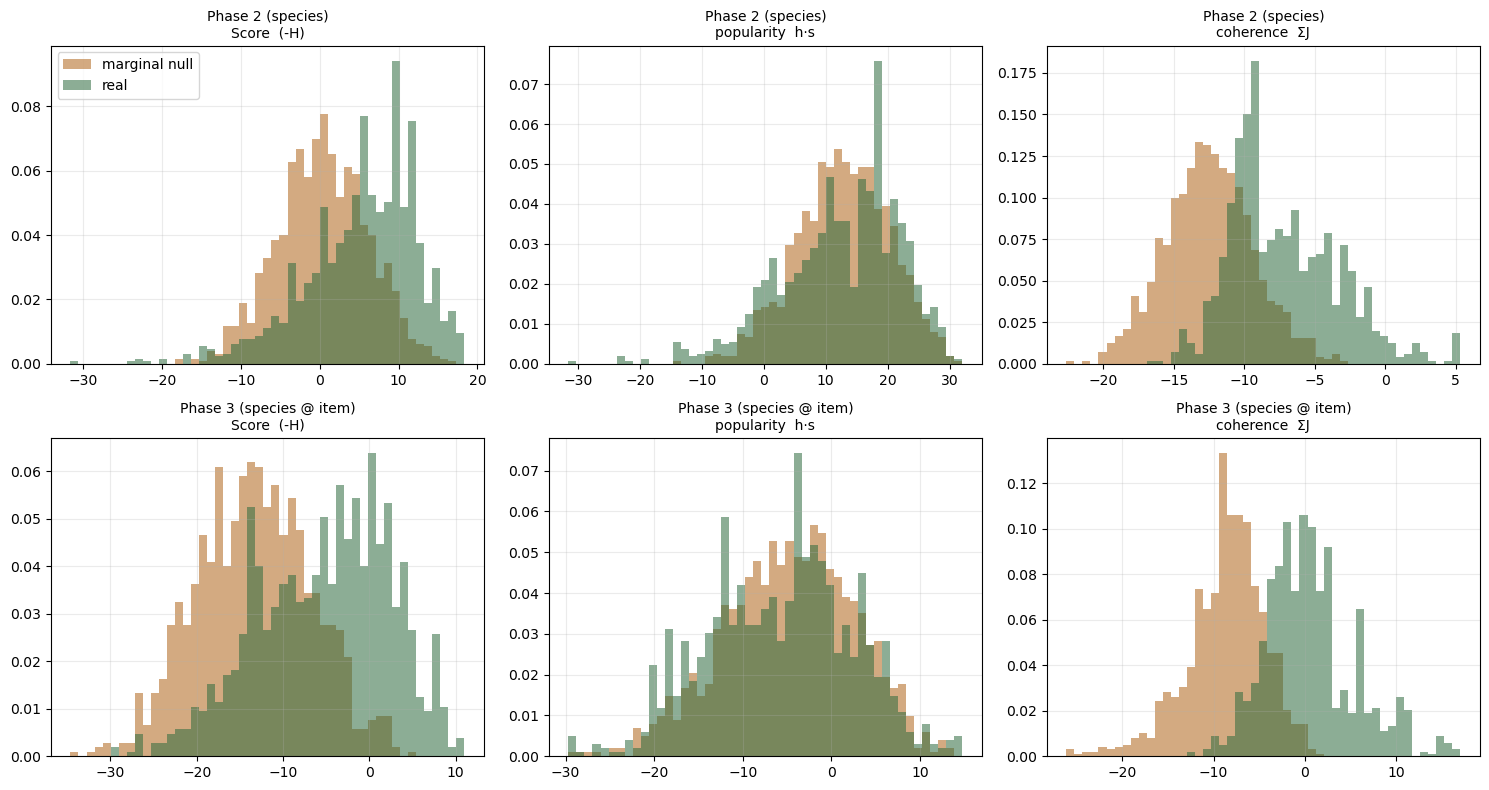

In [8]:
panels = [
    ("Phase 2 (species)", [
        ("Score  (-H)",        real_sp_score, null_sp_score),
        ("popularity  h·s",    real_sp_pop,   null_sp_pop),
        ("coherence  ΣJ",      real_sp_coh,   null_sp_coh),
    ]),
    ("Phase 3 (species @ item)", [
        ("Score  (-H)",        real_pr_score, null_pr_score),
        ("popularity  h·s",    real_pr_pop,   null_pr_pop),
        ("coherence  ΣJ",      real_pr_coh,   null_pr_coh),
    ]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for r, (row_title, cols) in enumerate(panels):
    for c, (title, real_v, null_v) in enumerate(cols):
        ax = axes[r, c]
        lo = min(real_v.min(), null_v.min())
        hi = max(real_v.max(), null_v.max())
        bins = np.linspace(lo, hi, 50)
        ax.hist(null_v, bins=bins, alpha=0.55, label="marginal null", color="#b0651a", density=True)
        ax.hist(real_v, bins=bins, alpha=0.55, label="real", color="#2e6b3f", density=True)
        ax.set_title(f"{row_title}\n{title}", fontsize=10)
        ax.grid(alpha=0.25)
        if r == 0 and c == 0:
            ax.legend()
plt.tight_layout()
plt.show()

## Discrimination: AUC

AUC $= P(\text{Score}_{\text{real}} > \text{Score}_{\text{null}})$ — the probability the model ranks a random real team above a random null team. Computed (tie-aware, via the Mann–Whitney rank identity) for full Score and for each term separately. The expected signature of a model whose discrimination comes from pairwise structure: **coherence AUC $\gg$ popularity AUC $\approx 0.5$**. Full Score lies in between — and note it need not beat coherence: $h\cdot s$ is the larger-magnitude term, so blending in a weakly-discriminative popularity signal can *lower* the combined AUC below coherence alone.

In [9]:
def auc(pos, neg):
    '''P(pos > neg), tie-corrected, via the rank-sum identity.'''
    allv = np.concatenate([pos, neg])
    r = rankdata(allv)
    n_pos = len(pos)
    return (r[:n_pos].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * len(neg))

rows = [
    ("Phase 2 (species)",
     (real_sp_score, null_sp_score), (real_sp_pop, null_sp_pop), (real_sp_coh, null_sp_coh)),
    ("Phase 3 (species @ item)",
     (real_pr_score, null_pr_score), (real_pr_pop, null_pr_pop), (real_pr_coh, null_pr_coh)),
]

print(f"{'model':<26} {'Score':>8} {'popularity':>12} {'coherence':>11}")
print("-" * 60)
for name, sc, pop, coh in rows:
    print(f"{name:<26} {auc(*sc):>8.3f} {auc(*pop):>12.3f} {auc(*coh):>11.3f}")

model                         Score   popularity   coherence
------------------------------------------------------------
Phase 2 (species)             0.726        0.511       0.864
Phase 3 (species @ item)      0.785        0.462       0.939


## Sweeping the bias dial (`field_weight`)

The two AUC extremes above are the endpoints of one knob. The app's `field_weight` $\alpha$ rescales the bias term — adjusted energy $H_\alpha(s) = -(\alpha h)\cdot s - \tfrac{1}{2} s'Js$, so the adjusted **Score** is

$$-H_\alpha(s) = \alpha\,(h\cdot s) + \Sigma J.$$

$\alpha = 0$ is coherence-only (popularity prior dropped); $\alpha = 1$ is raw energy. Because `pop` and `coh` are already computed per team, the whole sweep is a cheap reweighting — **no re-fit, no re-sampling**.

This tests the hypothesis that the best discrimination is *interior*. It usually is: the AUC-maximizing linear combination of two score components is the Fisher-discriminant direction, which generally mixes both rather than sitting at an endpoint. The sweep dips slightly below 0 only to locate the unconstrained optimum — negative `field_weight` (actively *penalizing* popularity) isn't a setting the app exposes.

model                       peak AUC   @ fw     fw=0   fw=1
------------------------------------------------------------
Phase 2 (species)              0.949  +0.25    0.864  0.726
Phase 3 (species @ item)       0.950  +0.15    0.939  0.785


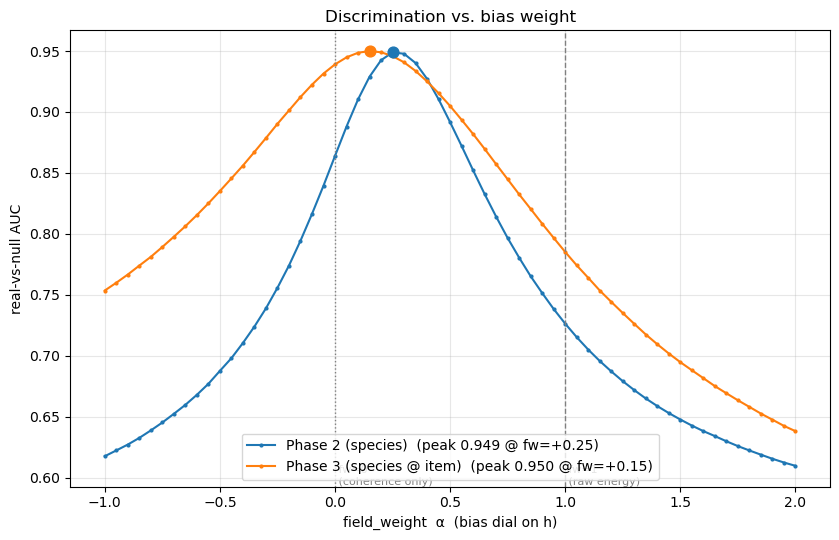

In [10]:
field_weights = np.linspace(-1.0, 2.0, 61)  # -1..2; slightly negative to locate the true peak

def auc_at_fw(pop_real, coh_real, pop_null, coh_null, fw):
    return auc(fw * pop_real + coh_real, fw * pop_null + coh_null)

sweep = {
    "Phase 2 (species)":        (real_sp_pop, real_sp_coh, null_sp_pop, null_sp_coh),
    "Phase 3 (species @ item)": (real_pr_pop, real_pr_coh, null_pr_pop, null_pr_coh),
}

fig, ax = plt.subplots(figsize=(8.5, 5.5))
i0 = int(np.argmin(np.abs(field_weights - 0.0)))
i1 = int(np.argmin(np.abs(field_weights - 1.0)))
print(f"{'model':<26} {'peak AUC':>9} {'@ fw':>6}   {'fw=0':>6} {'fw=1':>6}")
print("-" * 60)
for name, (pr, cr, pn, cn) in sweep.items():
    aucs = np.array([auc_at_fw(pr, cr, pn, cn, fw) for fw in field_weights])
    bi = int(aucs.argmax())
    line, = ax.plot(field_weights, aucs, marker=".", markersize=4,
                    label=f"{name}  (peak {aucs[bi]:.3f} @ fw={field_weights[bi]:+.2f})")
    ax.scatter([field_weights[bi]], [aucs[bi]], color=line.get_color(), zorder=5, s=60)
    print(f"{name:<26} {aucs[bi]:>9.3f} {field_weights[bi]:>+6.2f}   {aucs[i0]:>6.3f} {aucs[i1]:>6.3f}")

ax.axvline(0.0, color="gray", ls=":", lw=1)
ax.axvline(1.0, color="gray", ls="--", lw=1)
ax.text(0.0, ax.get_ylim()[0], " fw=0\n (coherence only)", va="bottom", fontsize=8, color="gray")
ax.text(1.0, ax.get_ylim()[0], " fw=1\n (raw energy)", va="bottom", fontsize=8, color="gray")
ax.set_xlabel("field_weight  α  (bias dial on h)")
ax.set_ylabel("real-vs-null AUC")
ax.set_title("Discrimination vs. bias weight")
ax.grid(alpha=0.3)
ax.legend(loc="lower center")
plt.tight_layout()
plt.show()

## Interpretation

Read the AUC table and the `field_weight` sweep together.

- **The validation passes, and coherence carries it.** Coherence AUC is high (~0.84 species, ~0.94 species @ item this run) — real teams stack mutually-reinforcing pairs (archetype cores) that independent marginal draws scatter. This is the pairwise model earning its keep over an independent one: the VGC instance of the Schneidman et al. (2006) result.
- **Popularity is weak alone (~0.56) but *complementary*.** On its own the popularity term ($h\cdot s$) barely separates the populations — by construction the null is drawn from the marginal distribution, so the $h\cdot s$ histograms nearly coincide while the $\Sigma J$ panels are cleanly shifted. But weak-alone is not uninformative: the sweep shows a *little* bias lifts AUC above coherence-only (peak ~0.945 / ~0.960 vs ~0.85 / ~0.92 at $\alpha=0$). A gain from a near-chance feature is the Fisher/LDA signature — $h\cdot s$ and $\Sigma J$ are conditionally complementary, so the optimal mix beats either term.
- **The bias dial has an interior optimum (~0.25–0.30 this run); $\alpha=1$ overweights it.** Raw energy ($\alpha=1$) sits *below* coherence-only because $h\cdot s$ is the high-magnitude, high-variance term: at full weight it dominates the score and drowns the cleaner coherence signal. The fix is not to drop the prior ($\alpha=0$) but to *scale it down* — the peak is firmly between the endpoints. So what looked like "the prior dilutes" is really "the prior is mis-scaled at 1.0"; at ~¼ strength it adds orthogonal signal rather than noise. Quantitative backing for keeping `field_weight` adjustable — and a hint that a default below 1 may discriminate better.
- **Phase 3 sharpens it** (peak ~0.96 vs ~0.945; coherence ~0.94 vs ~0.84): item identity makes the rewarded co-occurrences cleaner, consistent with `validation.ipynb`'s Phase-3 headline. Both phases land on nearly the same optimal dial (~0.25–0.30), so the best bias weight isn't a granularity artifact.

**Caveat.** A high AUC here is a *sanity* result, not a calibration result — beating a random marginal null is an easy bar, since the null freely mixes incompatible archetype cores. It establishes that $J$ encodes genuine co-occurrence structure; it does **not** establish that the model's *probabilities* are calibrated, nor that it separates real teams from *plausible* near-miss teams (the questions `validation.ipynb` and a future near-miss-null study address). And the optimal `field_weight` found here maximizes real-vs-null *separation* — a different objective from completion accuracy or subjective suggestion quality — so read ~0.25–0.30 as evidence about the dial, not a value to hardcode everywhere.